# Определение стоимости автомобилей

**Описание проекта**

Сервис по продаже автомобилей с пробегом «Не бит, не крашен» разрабатывает приложение, чтобы привлечь новых клиентов. В нём можно будет узнать рыночную стоимость своего автомобиля.
Необходимо построить модель, которая умеет её определять. В нашем распоряжении данные о технических характеристиках, комплектации и ценах других автомобилей.
Критерии, которые важны заказчику:

* качество предсказания;
* время обучения модели;
* время предсказания модели.

## 1. Загрузка данных

Объявим необходмые библиотеки, загрузим датафреймы и выведем их основную информацию:

In [1]:
%%capture
!pip install --upgrade -q catboost
!pip install --upgrade -q phik
!pip install --upgrade -q shap

In [2]:
import pandas as pd
import os
import seaborn as sns
import numpy as np
import shap

from phik import phik_matrix
from phik.report import plot_correlation_matrix

import matplotlib.pyplot as plt
from matplotlib.ticker import FixedLocator

import lightgbm as lgb
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, MinMaxScaler, RobustScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor

from time import time

import warnings
warnings.filterwarnings('ignore')

In [3]:
! gdown #данные скрыты

/bin/bash: gdown: command not found


In [4]:
pth_1 = '/content/autos.csv'
pth_2 = '/datasets/autos.csv'

pd.set_option('display.max_columns', None)

if os.path.exists(pth_1):
    df = pd.read_csv(pth_1, parse_dates=['DateCrawled', 'DateCreated', 'LastSeen'],  sep = ',')
    display(df)
    display(df.info())
    print()
    display(df.isna().sum())
elif os.path.exists(pth_2):
    df = pd.read_csv(pth_2, parse_dates=['DateCrawled', 'DateCreated', 'LastSeen'],  sep = ',')
    display(df)
    display(df.info())
    print()
    display(df.isna().sum())
else:
    print('Путь к датафрейму не найден')

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31,0,60437,2016-04-06 10:17:21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
354364,2016-03-21 09:50:58,0,NaN,2005,manual,0,colt,150000,7,petrol,mitsubishi,yes,2016-03-21,0,2694,2016-03-21 10:42:49
354365,2016-03-14 17:48:27,2200,NaN,2005,NaN,0,NaN,20000,1,NaN,sonstige_autos,NaN,2016-03-14,0,39576,2016-04-06 00:46:52
354366,2016-03-05 19:56:21,1199,convertible,2000,auto,101,fortwo,125000,3,petrol,smart,no,2016-03-05,0,26135,2016-03-11 18:17:12
354367,2016-03-19 18:57:12,9200,bus,1996,manual,102,transporter,150000,3,gasoline,volkswagen,no,2016-03-19,0,87439,2016-04-07 07:15:26


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354369 entries, 0 to 354368
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   DateCrawled        354369 non-null  datetime64[ns]
 1   Price              354369 non-null  int64         
 2   VehicleType        316879 non-null  object        
 3   RegistrationYear   354369 non-null  int64         
 4   Gearbox            334536 non-null  object        
 5   Power              354369 non-null  int64         
 6   Model              334664 non-null  object        
 7   Kilometer          354369 non-null  int64         
 8   RegistrationMonth  354369 non-null  int64         
 9   FuelType           321474 non-null  object        
 10  Brand              354369 non-null  object        
 11  Repaired           283215 non-null  object        
 12  DateCreated        354369 non-null  datetime64[ns]
 13  NumberOfPictures   354369 non-null  int64   

None

DateCrawled              0
Price                    0
VehicleType          37490
RegistrationYear         0
Gearbox              19833
Power                    0
Model                19705
Kilometer                0
RegistrationMonth        0
FuelType             32895
Brand                    0
Repaired             71154
DateCreated              0
NumberOfPictures         0
PostalCode               0
LastSeen                 0
dtype: int64

### Промежуточный вывод:

Данные загружены, соответствуют описанию.

## 2. Предобработка и исследовательский анализ данных

### Предварительный вывод графиков

Изучим датафрейм. Необходимо проверить данные на наличие аномалий и выбросов. Построим гистограммы распределения категориального и количественных признаков (для столбцов `fuel_type`, `model` и `brand` построить график не получится, т.к. уникальных значений слишком много - для них выведем статистику при помощи `value_counts`).

,Price
count,354369.00
mean,4416.66
median,2700.00
max,20000.00
min,0.00
10th_percentile,499.00
25th_percentile,1050.00
75th_percentile,6400.00
90th_percentile,11450.00


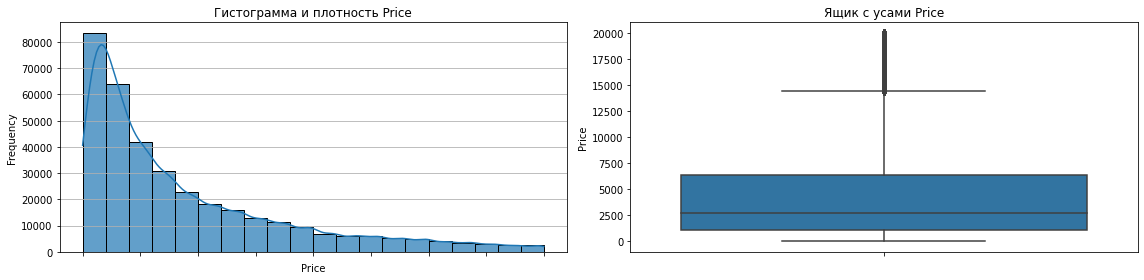

,RegistrationYear
count,354369.00
mean,2004.23
median,2003.00
max,9999.00
min,1000.00
10th_percentile,1995.00
25th_percentile,1999.00
75th_percentile,2008.00
90th_percentile,2012.00


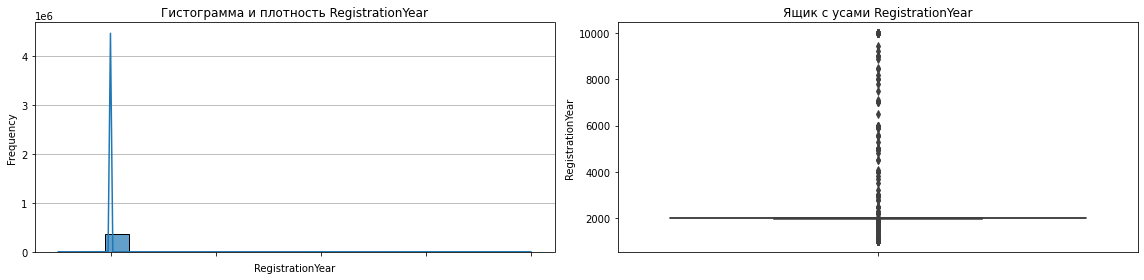

,Power
count,354369.00
mean,110.09
median,105.00
max,20000.00
min,0.00
10th_percentile,0.00
25th_percentile,69.00
75th_percentile,143.00
90th_percentile,179.00


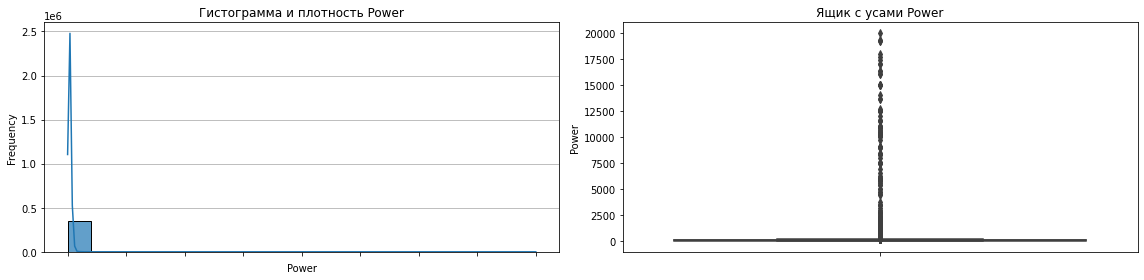

,Kilometer
count,354369.00
mean,128211.17
median,150000.00
max,150000.00
min,5000.00


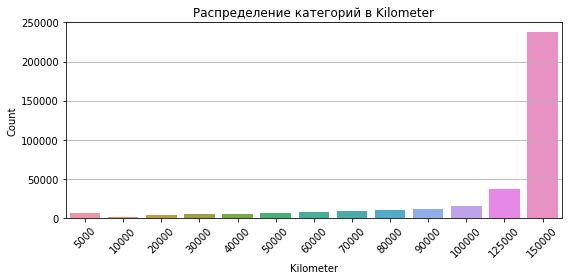

,RegistrationMonth
count,354369.00
mean,5.71
median,6.00
max,12.00
min,0.00


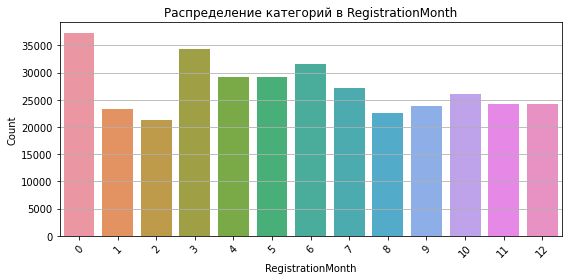

,NumberOfPictures
count,354369.0
mean,0.0
median,0.0
max,0.0
min,0.0


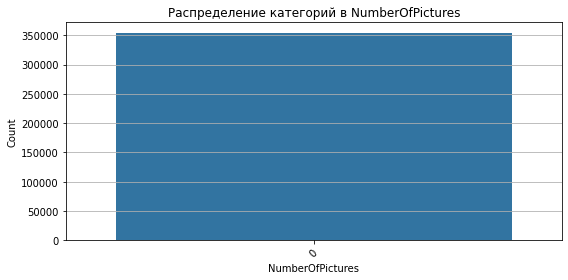

,PostalCode
count,354369.00
mean,50508.69
median,49413.00
max,99998.00
min,1067.00
10th_percentile,14959.00
25th_percentile,30165.00
75th_percentile,71083.00
90th_percentile,87776.00


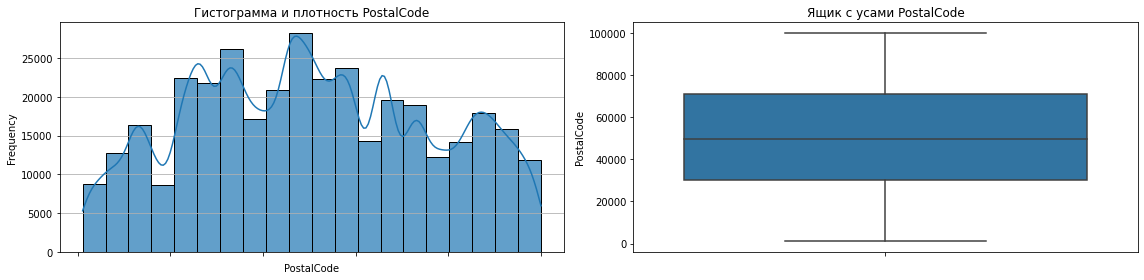

,DateCrawled
count,354369
max,2016-04-07 14:36:58
min,2016-03-05 14:06:22


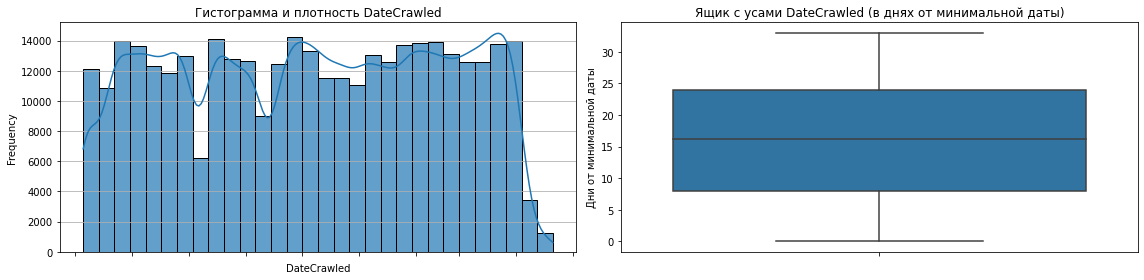

,DateCreated
count,354369
max,2016-04-07 00:00:00
min,2014-03-10 00:00:00


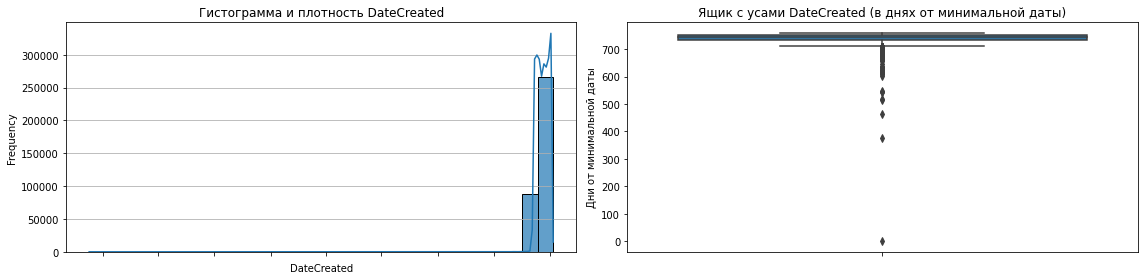

,LastSeen
count,354369
max,2016-04-07 14:58:51
min,2016-03-05 14:15:08


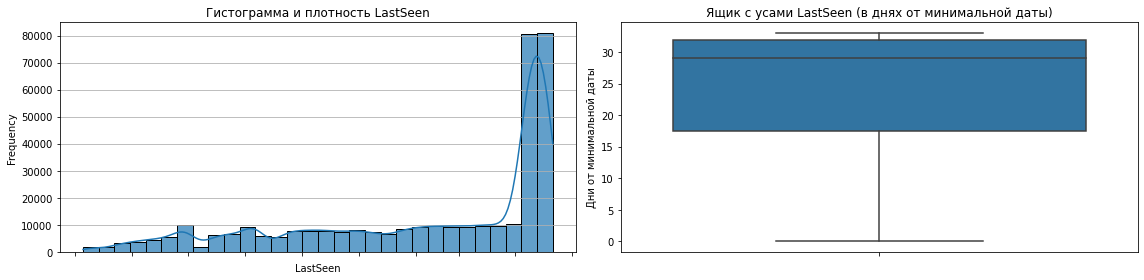

Уникальные значения в столбце VehicleType:
             VehicleType
sedan           0.288618
small           0.251929
wagon           0.205649
bus             0.090808
convertible     0.063756
coupe           0.051007
suv             0.037857
other           0.010376



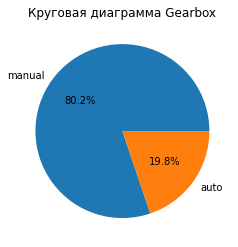

Уникальные значения в столбце Model:
                       Model
golf                0.087347
other               0.072972
3er                 0.059047
polo                0.039042
corsa               0.037560
...                      ...
serie_2             0.000024
rangerover          0.000012
serie_3             0.000012
serie_1             0.000006
range_rover_evoque  0.000006

[250 rows x 1 columns]

Уникальные значения в столбце FuelType:
          FuelType
petrol    0.673000
gasoline  0.307085
lpg       0.016518
cng       0.001758
hybrid    0.000725
other     0.000635
electric  0.000280

Уникальные значения в столбце Brand:
                   Brand
volkswagen      0.217324
opel            0.112682
bmw             0.104168
mercedes_benz   0.090431
audi            0.083122
ford            0.071053
renault         0.050589
peugeot         0.031035
fiat            0.027212
seat            0.019491
mazda           0.015845
skoda           0.015521
smart           0.014804
citroen   

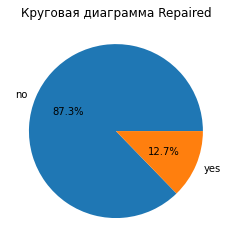

In [5]:
def histogram(data):
    '''
    Функция вывода таблицы параметров агрегации, построения графиков распределения значений и ящика с усами
    для каждого столбца с численными данными. В случае, если в данных присутствуют цифровые категориальные значения,
    можно вычленить данные столбцы и построить для них диаграммы countplot.
    
    Также есть опциональный цикл для работы с данными формата "datetime".
    
    Для текстовых категориальных столбцов создан отдельный цикл. В нём строятся круговые диаграммы,
    выводятся уникальные значения и их доля.
    
    Аргументы:
        data : pd.DataFrame
    '''
    # Обработка числовых данных
    numeric_cols = data.select_dtypes(include=['float64', 'int64']).columns
    for col in numeric_cols:
        if col != 'id' and data[col].nunique() > 13:
            fig, ax = plt.subplots(1, 2, figsize=(16, 4))
            # Расчет статистик
            stats = data[col].agg(['count', 'mean', 'median', 'max', 'min',
                                    lambda x: x.quantile(0.1),
                                    lambda x: x.quantile(0.25),
                                    lambda x: x.quantile(0.75),
                                    lambda x: x.quantile(0.9)])
            stats.index = ['count', 'mean', 'median', 'max', 'min',
                           '10th_percentile', '25th_percentile', '75th_percentile', '90th_percentile']
            display(round(stats.to_frame(), 2))
            
            # Гистограмма и график плотности
            sns.histplot(x=data[col], kde=True, bins=20, ax=ax[0], alpha=0.7)
            ax[0].set_title(f'Гистограмма и плотность {col}')
            ax[0].set_xlabel(col)
            ax[0].set_ylabel('Frequency')
            ax[0].grid(axis='y')
            ax[0].xaxis.set_major_locator(FixedLocator(ax[0].get_xticks()))
            ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45)
            
            # Ящик с усами
            sns.boxplot(y=data[col], ax=ax[1])
            ax[1].set_title(f'Ящик с усами {col}')
            ax[1].set_ylabel(col)
            
            plt.tight_layout()
            plt.show()
        elif col != 'id':
            # Для категориальных или дискретных данных
            display(round(data[col].agg(['count', 'mean', 'median', 'max', 'min']), 2).to_frame())
            plt.figure(figsize=(8, 4))
            sns.countplot(x=data[col])
            plt.title(f'Распределение категорий в {col}')
            plt.xlabel(col)
            plt.ylabel('Count')
            plt.grid(axis='y')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()

    # Обработка дат
    for col in data.select_dtypes(include='datetime').columns:
        display(data[col].agg(['count', 'max', 'min']).to_frame())
        fig, ax = plt.subplots(1, 2, figsize=(16, 4))
        sns.histplot(x=data[col], kde=True, bins=30, ax=ax[0], alpha=0.7)
        ax[0].set_title(f'Гистограмма и плотность {col}')
        ax[0].set_xlabel(col)
        ax[0].set_ylabel('Frequency')
        ax[0].grid(axis='y')
        ax[0].xaxis.set_major_locator(FixedLocator(ax[0].get_xticks()))
        ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=45)

        # Преобразуем дату в число (например, количество дней с минимальной даты)
        days_since_min = (data[col] - data[col].min()).dt.total_seconds() / (24*3600)
        sns.boxplot(y=days_since_min, ax=ax[1])
        ax[1].set_title(f'Ящик с усами {col} (в днях от минимальной даты)')
        ax[1].set_ylabel('Дни от минимальной даты')

        plt.tight_layout()
        plt.show()

    # Обработка категориальных данных (object)
    for col in data.select_dtypes(include='object').columns:
        if col not in ['model', 'fuel_type', 'brand', 'VehicleType', 'Model', 'FuelType', 'Brand']:
            counts = data[col].value_counts()
            plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
            plt.title(f'Круговая диаграмма {col}')
            plt.show()
        else:
            print(f"Уникальные значения в столбце {col}:\n{data[col].value_counts(normalize=True).to_frame()}\n")


histogram(df)

### Предобработка данных

Проведём необходимую предобработку данных.

* приведём имена столбцов к стандартному виду;
* в столбце `price` присутствуют нулевые, а также значительно малые значения. Т.к. автомобиль не может быть бесплатным или почти бесплатным, заменим все значения менее 500 евро на медианные значения. *Заказчику рекомендуется добавить в анкету ограничение на минимальную цену для исключения подобных ошибок*;
* аналогично поступим со столбцом `power`: лошадиные силы также не могут быть нулевыми или слишком маленькими, а также слишком большими. Вероятно, при заполнении анкет пользователями были допущены те или иные ошибки. Заменим все значения менее 60 л.с. на медианные значения, а свыше 600 л.с. - на 600 л.с. *Заказчику рекомендуется добавить в анкету ограничение на минимальную и максимальную мщность двигателя*;
* в столбце `reg_year` удалим значения "из будущего" (моложе 2016 года - когда был выгружен датасет), а также "исторические" (XX век и старше - предлагаем ограничиться 50-летним интервалом, вероятность нарваться на более старую машину минимальна). Вероятнее всего, такие значения связаны с ошибкой при внесении данных пользователями. *Заказчику предлагается по данному столбцу оформить внесение информации через жёсткий список*;
* в категориальном столбце `reg_month` обнаружено значение "0". Вероятно, эти значения присваиваются как "заглушки" тем анкетам, в которых пользователи не указали месяц. Предлагаем распределить данные значения пропорционально имеющимся месяцам. *Заказчику также предлагается по данному столбцу оформить внесение информации через жёсткий список*;
* удалим столбец `num_pict` - он неинформативен, т.к. заполнен нулями;
* также удалим столбцы с датами - невозможно будет воспроизводить эти признаки для новых клиентов, у которых ещё нет анкеты. Тем более, если сервис клиента не предполагает создание анкет в будущем;
* пропуски в столбцах `veh_type`, `gearbox`, `model` и `fuel_type` заполним заглушкой "other";
* пропуски в столбце `repaired` заполним заглушкой "unknown".


In [6]:
df.rename(columns={'DateCrawled': 'date_crawled', 'Price': 'price', 'VehicleType': 'veh_type', \
                   'RegistrationYear': 'reg_year', 'Gearbox': 'gearbox', 'Power': 'power', \
                   'Model': 'model', 'Kilometer': 'kilometer', 'RegistrationMonth': 'reg_month', \
                   'FuelType': 'fuel_type', 'Brand': 'brand', 'Repaired': 'repaired', \
                   'DateCreated': 'date_created', 'NumberOfPictures': 'num_pict', 'PostalCode': 'post_code', 'LastSeen': 'last_seen'}, inplace=True)

display(df.columns)

median_price = df['price'].median()
median_power = df['power'].median()

df['price'] = df['price'].apply(lambda x: median_price if x < 500 else x)

Index(['date_crawled', 'price', 'veh_type', 'reg_year', 'gearbox', 'power',
       'model', 'kilometer', 'reg_month', 'fuel_type', 'brand', 'repaired',
       'date_created', 'num_pict', 'post_code', 'last_seen'],
      dtype='object')

In [7]:
df['power'] = df['power'].apply(lambda x: median_power if x < 60 else x)
df['power'] = df['power'].apply(lambda x: 600 if x > 600 else x)

In [8]:
df.query('reg_year <= 2016 and reg_year >= 1974', inplace=True)

In [9]:
# Сначала подсчитаем количество вхождений каждого месяца, исключая "0"
month_counts = df[df['reg_month'] != 0]['reg_month'].value_counts(normalize=True)

# Теперь распределим "0" пропорционально
zero_indices = df[df['reg_month'] == 0].index
np.random.seed(0)  # Для воспроизводимости
df.loc[zero_indices, 'reg_month'] = np.random.choice(
    month_counts.index,
    size=len(zero_indices),
    p=month_counts.values
)

In [10]:
df.drop(['num_pict', 'date_created', 'date_crawled', 'last_seen'], axis=1, inplace=True)

In [11]:
for col in ['veh_type', 'gearbox', 'model', 'fuel_type']:
    df[col].fillna('other', inplace=True)

df['repaired'].fillna('unknown', inplace=True)

print()
print('Количество пропусков: \n')
display(df.isna().sum())


Количество пропусков: 



price        0
veh_type     0
reg_year     0
gearbox      0
power        0
model        0
kilometer    0
reg_month    0
fuel_type    0
brand        0
repaired     0
post_code    0
dtype: int64

### Исследовательский анализ данных

Повторно построим графики, проведём исследовательский анализ данных.

,price
count,337615.00
mean,4708.94
median,2790.00
max,20000.00
min,500.00
10th_percentile,899.00
25th_percentile,1600.00
75th_percentile,6499.00
90th_percentile,11500.00


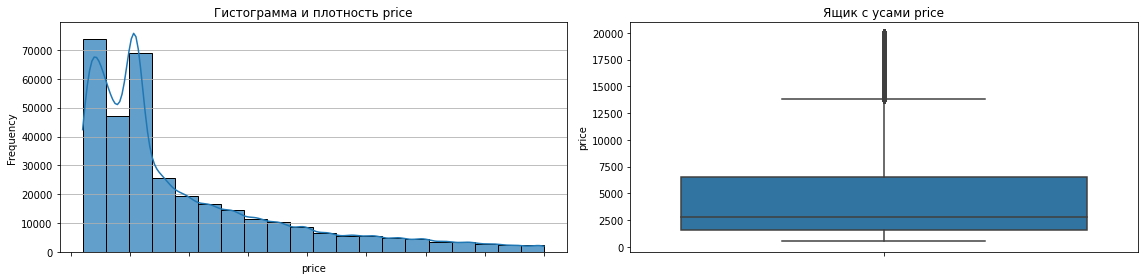

,reg_year
count,337615.00
mean,2002.73
median,2003.00
max,2016.00
min,1974.00
10th_percentile,1995.00
25th_percentile,1999.00
75th_percentile,2007.00
90th_percentile,2011.00


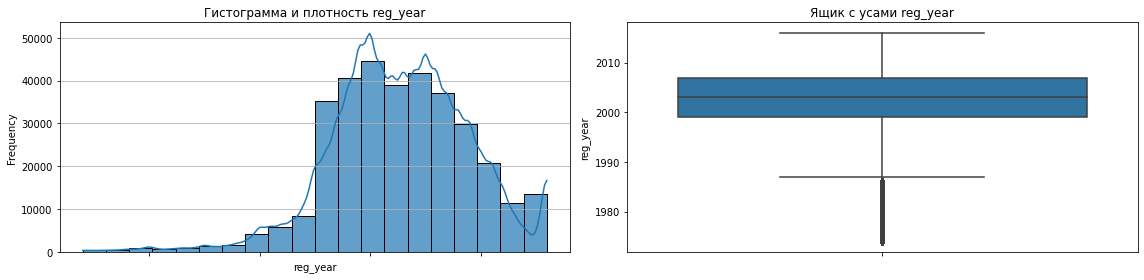

,power
count,337615.00
mean,122.98
median,105.00
max,600.00
min,60.00
10th_percentile,75.00
25th_percentile,97.00
75th_percentile,143.00
90th_percentile,180.00


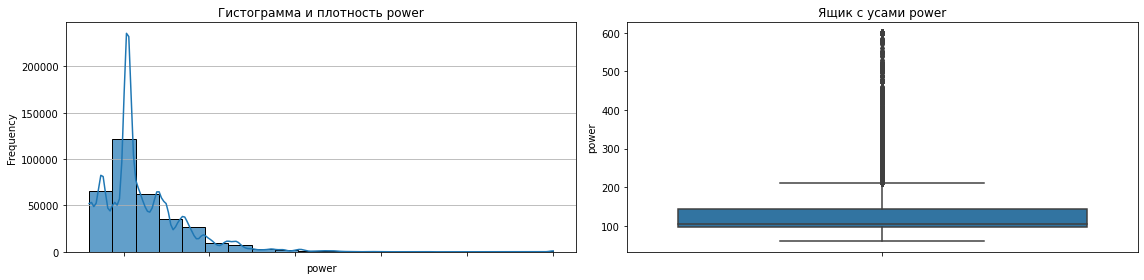

,kilometer
count,337615.0
mean,128399.2
median,150000.0
max,150000.0
min,5000.0


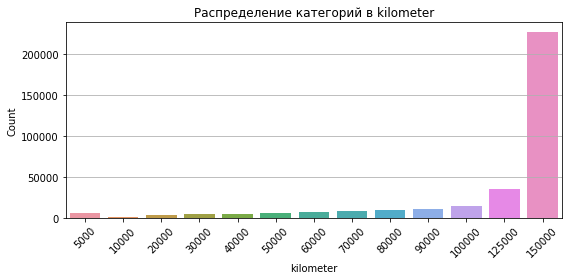

,reg_month
count,337615.00
mean,6.39
median,6.00
max,12.00
min,1.00


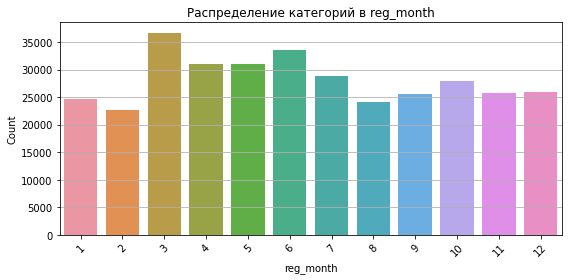

,post_code
count,337615.0
mean,50614.7
median,49497.0
max,99998.0
min,1067.0
10th_percentile,14979.0
25th_percentile,30173.0
75th_percentile,71229.0
90th_percentile,88045.0


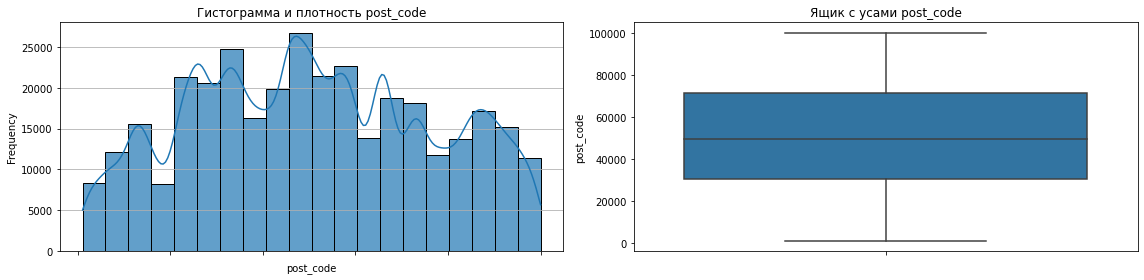

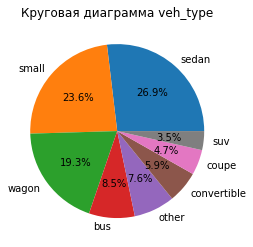

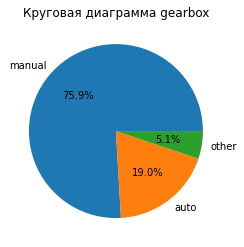

Уникальные значения в столбце model:
                       model
other               0.118369
golf                0.081765
3er                 0.056929
polo                0.036870
corsa               0.035348
...                      ...
serie_3             0.000009
serie_2             0.000009
rangerover          0.000009
range_rover_evoque  0.000006
serie_1             0.000003

[250 rows x 1 columns]

Уникальные значения в столбце fuel_type:
          fuel_type
petrol     0.617591
gasoline   0.285073
other      0.079564
lpg        0.015254
cng        0.001596
hybrid     0.000661
electric   0.000261

Уникальные значения в столбце brand:
                   brand
volkswagen      0.215758
opel            0.111983
bmw             0.105831
mercedes_benz   0.091160
audi            0.084256
ford            0.071019
renault         0.050057
peugeot         0.031400
fiat            0.026714
seat            0.019353
mazda           0.015980
skoda           0.015835
smart           0.014896
c

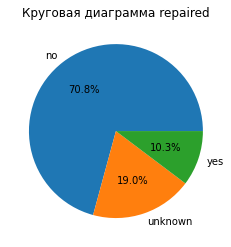

In [12]:
histogram(df)

### Промежуточные выводы:

* в столбце `price` наблюдается распределение со смещением влево и двумя пиками: второй пик возле медианы обусловлен заполнением пропусков;
* в столбце `reg_wear` наблюдается распределение со смещением вправо и двумя пиками. Минимальное количество регистраций до 1990г. обусловлено дефицитом производимых транспортных средств в СССР. Локальное падение регистраций в районе 2012г. обусловлено, вероятно, последствиями экономического кризиса 2008г. и последующей рецессии;
* в столбце `power` наблюдается распределение со смещением влево: выбросы обусловлены незначительным количеством транспорта с мощностью двигателя свыше 200-300 л.с.;
* в столбце `kilometer` наблюдается выброс в категории "150000": очевидно, что машины с большим пробегом занимают подавляющую долю от общего числа;
* в столбце `month` наблюдается относительно равномерное распределение по месяцам;
* в столбце `post_code` прослеживается нормальное распределение с локальными провалами и пиками. Скорее всего, это связано с тем, что в крупных городах количество анкет по автомобилям выше, чем в маленьких городах и сельской местности;
* значения в категориальных столбцах выглядят корректно.

## 2. Корреляционный анализ

Проведём корреляционный анализ признаков с помощью матрицы корреляции `phik_matrix()` и сделаем выводы о мультиколлинеарности и при необходимости устраним её. Также проверим данные на утечку целевого параметра.

In [13]:
interval_cols = ['price', 'power', 'post_code']

In [14]:
phik_overview = phik_matrix(df, interval_cols=interval_cols)

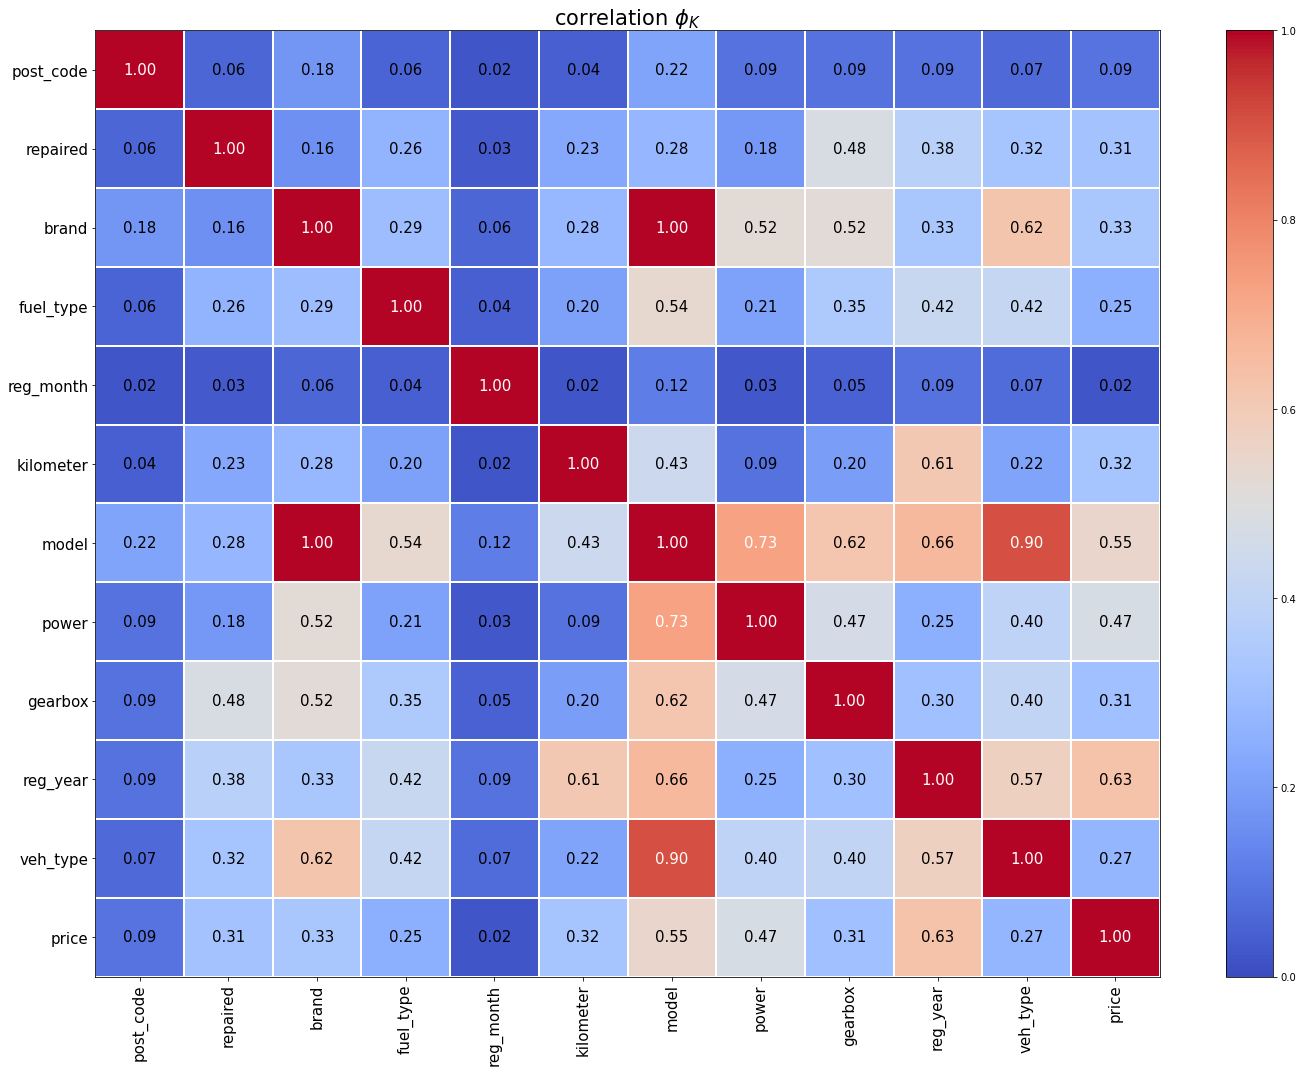

In [15]:
plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='coolwarm',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
)

### Промежуточный вывод:

Очевидна зависимость цены автомобиля от параметров `reg_year`, `model`, `power` и `kilometer` - чем меньше возраст машины, её пробег, выше мощность двигателя, "элитность" модели, тем цена выше.

Удалим параметры `reg_month` и `post_code`: месяц постановки на учёт и регион регистрации владельца авто вряд ли повлияет на цену.

После всех манипуляций проверим датасет на полные дубликаты и удалим их.

In [16]:
df.drop(['reg_month', 'post_code'], axis=1, inplace=True)
df.drop_duplicates(inplace=True)

## 3. Обучение моделей

Использовать будем модель градиентного бустинга `LGBMRegressor()`и модель линейной регрессии.

Кодирование категориальных признаков и стандартизация числовых проведём с помощью пайплайна.

Оценку модели проведём при помощи метрики `RMSE`.

In [17]:
# Генерация набора данных
X = df.copy()
X = df.drop(columns='price')
y = df['price'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
    )


### Модель LightGBM

In [18]:
cat_cols = ['repaired', 'brand', 'fuel_type', 'gearbox', 'reg_year', 'veh_type', 'model']
num_cols = ['power']
ord_cols = ['kilometer']

In [19]:
ohe_pipe = Pipeline(
    [
        ('simpleImputer_ohe', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
        ('ohe', OneHotEncoder(drop='first', handle_unknown='error', sparse=False))
    ]
)

ord_pipe = Pipeline(
    [('simpleImputer_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
     ('ord',  OrdinalEncoder(
                categories = [[5000, 10000, 20000, 30000, 40000, 50000, 60000, 70000, 80000, 90000, 100000, 125000, 150000]],
                handle_unknown='use_encoded_value', unknown_value=np.nan
            )
        ),
     ('simpleImputer_after_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent'))
    ]
)

In [20]:
for col in cat_cols:
    X_train[col] = X_train[col].astype('category')
    X_test[col] = X_test[col].astype('category')

data_preprocessor_boost = ColumnTransformer([
    ('ord', ord_pipe, ord_cols),
    ('ohe', ohe_pipe, cat_cols),
    ('num', MinMaxScaler(), num_cols)
], remainder='passthrough')

# Обновленный пайплайн с предварительной обработкой и моделью LightGBM
pipeline_boost = Pipeline([
    ('preprocessor', data_preprocessor_boost),
    ('lgbm', lgb.LGBMRegressor(random_state=42))
])

In [21]:
# Параметры для подбора
param_grid = {

    'lgbm__learning_rate': [0.01, 0.1, 0.5],
    'lgbm__n_estimators': [100, 200, 500]
}



# Подбор гиперпараметров
grid_search = GridSearchCV(
    pipeline_boost,
    param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',
    verbose=0
    )



In [22]:
grid_search.fit(X_train, y_train)

print('Параметры лучшей модели:\n\n', grid_search.best_estimator_)
print ('Метрика RMSE лучшей модели на кросс-валидации:', round(- grid_search.best_score_, 2))

Параметры лучшей модели:

 Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('ord',
                                                  Pipeline(steps=[('simpleImputer_before_ord',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ord',
                                                                   OrdinalEncoder(categories=[[5000,
                                                                                               10000,
                                                                                               20000,
                                                                                               30000,
                                                                                               40000,
                                    

In [23]:
model = grid_search.best_estimator_

start = time()

model.fit(X_train, y_train) #замеряем время обучения

end = time()

print('Время обучения, минут:', round((end-start)/60, 2))

start = time()

model.predict(X_train) #замеряем время предсказания

end = time()

print('Время предсказания, минут:', round((end-start)/60, 2))

Время обучения, минут: 0.46
Время предсказания, минут: 0.05


### Модель линейной регрессии

In [24]:
cat_cols_linear = ['repaired', 'brand', 'fuel_type', 'gearbox', 'reg_year', 'veh_type', 'model', 'kilometer']

data_preprocessor_linear = ColumnTransformer([
    ('ohe', ohe_pipe, cat_cols_linear),
    ('num', MinMaxScaler(), num_cols)
], remainder='passthrough')

In [25]:
pipe_final_linear = Pipeline(
    [
        ('preprocessor', data_preprocessor_linear),
        ('models', LinearRegression())
    ]
)

In [26]:
linear = cross_val_score(pipe_final_linear, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')

print ('Метрика RMSE модели линейной регрессии на кросс-валидации:', round( - linear.mean(), 2))

start = time()

pipe_final_linear.fit(X_train, y_train) #замеряем время обучения

end = time()

print('Время обучения, минут:', round((end-start)/60, 2))

start = time()

pipe_final_linear.predict(X_train) #замеряем время предсказания

end = time()

print('Время предсказания, минут:', round((end-start)/60, 2))

Метрика RMSE модели линейной регрессии на кросс-валидации: nan
Время обучения, минут: 0.41
Время предсказания, минут: 0.03


### Промежуточный вывод:

Лучше всего на тренировочных данных проявила себя модель LightGBM:

* её метрика лучше метрики линейной регрессии в два раза (1713.15 против 2189.25);
* суммарное время обучения и предсказания также ниже, чем у линейной регрессии (0.16+0.1 против 0.4+0.14).


### Анализ остатков

In [27]:
# Предсказание и оценка RMSE
y_pred = model.predict(X_test)
rmse = round(np.sqrt(mean_squared_error(y_test, y_pred)), 2)
print(f'RMSE: {rmse}')

RMSE: 2968.93


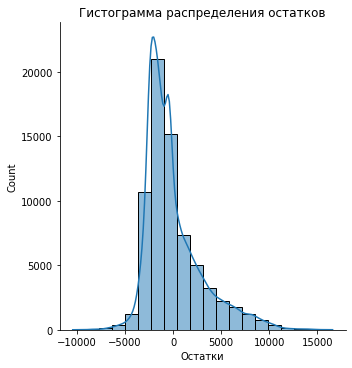

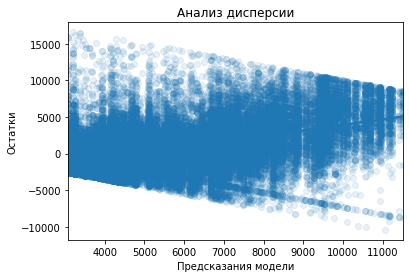

In [28]:
residuals = y_test - y_pred

sns.displot(residuals, kde=True, multiple='stack', bins=20)
plt.title('Гистограмма распределения остатков')
plt.xlabel('Остатки')
plt.show()

fig, ax = plt.subplots()
sns.regplot(x=y_pred, y=residuals, fit_reg=True, scatter_kws={'alpha': 0.1})
plt.xlabel('Предсказания модели')
plt.ylabel('Остатки')
plt.title('Анализ дисперсии')
plt.show()

### Константная модель DummyRegressor

In [29]:
dummy_reg = DummyRegressor(strategy='mean')

dummy_reg.fit(X_train, y_train)

y_pred_dummy = dummy_reg.predict(X_test)

rmse = round(np.sqrt(mean_squared_error(y_test, y_pred_dummy)), 2)
print(f'RMSE: {rmse}')

RMSE: 4436.64


### Промежуточный вывод:

Модель LightGBM отлично справилась с задачей предсказания цены на тестовом наборе:

* RMSE модели ниже необходимого порога (1708.87);
* гистограмма распределения практически симметричная, правильная;
* дисперсия предсказаний равномерна по всему диапазону. Однако, можно заметить тенденцию с неудачными предсказаниями цен на машины из топ-сегмента: скорее всего, это связано с тем, что данных предложений значительно меньше по сравнению с низким и средним ценовми сегментами;
* проверочная константная модель работает гораздо хуже.


## 4. Анализ важности признаков:

Оценим важность признаков для лучшей модели и построим графики важности с помощью метода SHAP.

Количество признаков после преобразований: 349
Количество имен признаков: 349


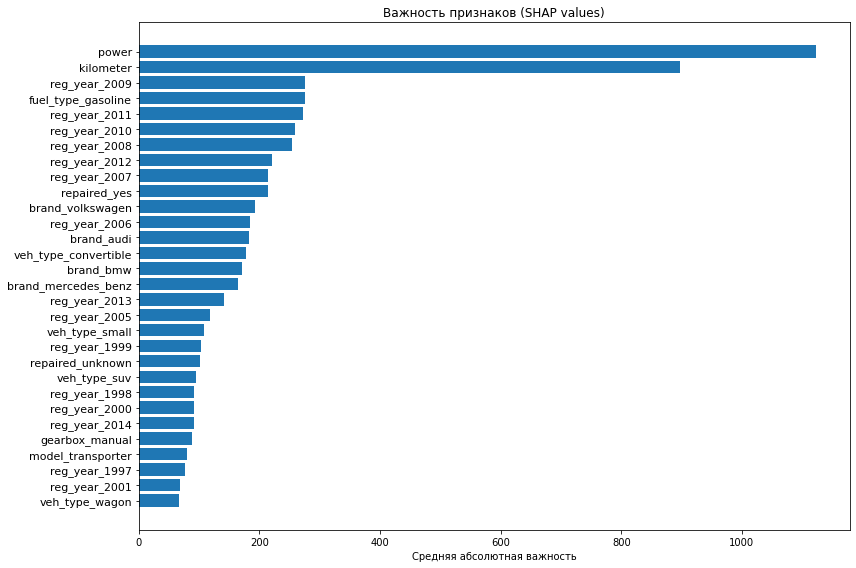

In [30]:
def get_feature_names_out(column_transformer):
    """Получаем правильные имена признаков после всех преобразований"""
    feature_names = []
    
    for name, transformer, columns in column_transformer.transformers_:
        if name == 'remainder':
            continue
            
        if transformer == 'passthrough':
            feature_names.extend(columns)
            continue
            
        if hasattr(transformer, 'get_feature_names_out'):
            # Для OneHotEncoder и других новых трансформеров
            names = transformer.get_feature_names_out(columns)
        elif hasattr(transformer, 'get_feature_names'):
            # Для старых версий sklearn
            names = transformer.get_feature_names(columns)
        elif hasattr(transformer, 'named_steps'):
            # Для пайплайнов внутри ColumnTransformer
            names = []
            for step_name, step in transformer.named_steps.items():
                if hasattr(step, 'get_feature_names_out'):
                    names = step.get_feature_names_out(columns)
                elif hasattr(step, 'get_feature_names'):
                    names = step.get_feature_names(columns)
                elif hasattr(step, 'categories_'):
                    # Для OrdinalEncoder
                    names = columns  # или можно добавить суффиксы
        else:
            # Для простых трансформеров (MinMaxScaler и т.д.)
            names = columns
            
        feature_names.extend(names)
    
    return feature_names

# Получаем имена признаков
preprocessor = grid_search.best_estimator_.named_steps['preprocessor']
feature_names = get_feature_names_out(preprocessor)

# Проверяем количество признаков
X_train_transformed = preprocessor.transform(X_train)
print(f"Количество признаков после преобразований: {X_train_transformed.shape[1]}")
print(f"Количество имен признаков: {len(feature_names)}")

# Если все совпадает, продолжаем с SHAP
if X_train_transformed.shape[1] == len(feature_names):
    # Обучаем модель на преобразованных данных
    X_train_ = preprocessor.fit_transform(X_train)
    X_test_ = preprocessor.transform(X_test)
    
    model_shap = lgb.LGBMRegressor(n_estimators=500, random_state=42)
    model_shap.fit(X_train_, y_train, feature_name=feature_names)
    
    # SHAP анализ
    explainer = shap.Explainer(model_shap, feature_names=feature_names)
    shap_values = explainer(X_test_)
    
    # Визуализация
    shap_importance = np.abs(shap_values.values).mean(0)
    top_n = min(30, len(feature_names))
    sorted_idx = np.argsort(shap_importance)[-top_n:]
    
    plt.figure(figsize=(12, 8))
    plt.barh(range(len(sorted_idx)), shap_importance[sorted_idx], align='center')
    plt.yticks(range(len(sorted_idx)), np.array(feature_names)[sorted_idx], fontsize=11)
    plt.title('Важность признаков (SHAP values)')
    plt.xlabel('Средняя абсолютная важность')
    plt.tight_layout()
    plt.show()
else:
    print("Ошибка: количество признаков не совпадает с количеством имен")
    print("Проверьте функцию get_feature_names_out для ваших трансформеров")

### Промежуточный вывод:

Наиболее важными признаками для модели оказались признаки:

* мощность двигателя - закономерно, что автомобили с более мощным двигателем будут стоить дороже, чем малолитражные;
* пробег - чем он меньше, тем автомобиль дороже;
* год регистрации - очевидно, что чем меньше возраст машины, тем она дороже;
* проведение восстановительных работ - машины после аварий будут стоить дешевле;
* тип топлива - вероятно, из-за особенностей питания двигателей различными видами топлива  зависит цена "механической" составляющей;
* бренд - от "статусности" и "доверию" к бренду цена также имеет зависимость.

## Общий вывод:

**Описание проекта**

Сервис по продаже автомобилей с пробегом «Не бит, не крашен» разрабатывает приложение, чтобы привлечь новых клиентов. В нём можно будет узнать рыночную стоимость своего автомобиля.

**Задача:** Необходимо построить модель, которая умеет её определять. В нашем распоряжении данные о технических характеристиках, комплектации и ценах других автомобилей.
Критерии, которые важны заказчику:

* качество предсказания;
* время обучения модели;
* время предсказания модели.

**Примечания:**
* Для оценки качества моделей необходимо применять метрику RMSE;
* Значение метрики RMSE должно быть меньше 2500.

**Описание данных:**

Признаки:

    DateCrawled — дата скачивания анкеты из базы
    VehicleType — тип автомобильного кузова
    RegistrationYear — год регистрации автомобиля
    Gearbox — тип коробки передач
    Power — мощность (л. с.)
    Model — модель автомобиля
    Kilometer — пробег (км)
    RegistrationMonth — месяц регистрации автомобиля
    FuelType — тип топлива
    Brand — марка автомобиля
    Repaired — была машина в ремонте или нет
    DateCreated — дата создания анкеты
    NumberOfPictures — количество фотографий автомобиля
    PostalCode — почтовый индекс владельца анкеты (пользователя)
    LastSeen — дата последней активности пользователя

Целевой признак:

    Price — цена (евро)

**В ходе предобработки данных было сделано:**

* приведены имена столбцов к стандартному виду;
* удалены нулевые, значительно малые и слишком большие значения там, где это было необходимо;
* во "временных" столбцах удалены значения "из будущего", "исторические", а также те строки, которые были созданы перед массовым внедрением базы для заполнения клиентами;
* в категориальном столбце `reg_month` избавились от "заглушки";
* удалён неинформативный столбец `num_pict`;
* также удалены столбцы с датами - невозможно будет воспроизводить эти признаки для новых клиентов, у которых ещё нет анкеты. Тем более, если сервис клиента не предполагает создание анкет в будущем;
* пропуски в столбцах заполнены заглушками;
* ***объяснена природа аномальных значений в параметрах, даны рекомендации клиенту по повышению качества данных***.

**Проведён корреляционный анализ признаков:**

С помощью матрицы корреляции `phik_matrix()` сделаны выводы о мультиколлинеарности и утечке целевого параметра.

Очевидна зависимость цены автомобиля от параметров `reg_year`, `model`, `power` и `kilometer` - чем меньше возраст машины, её пробег, выше мощность двигателя, "элитность" модели, тем цена выше.

Удалён параметр `reg_month`: месяц постановки на учёт вряд ли повлияет на цену.

После всех манипуляций проверим датасет на полные дубликаты и удалим их.


**Обучение моделей**

Использована модель градиентного бустинга `LGBMRegressor()`и модель линейной регрессии, а также проведена проверка константной моделью DummyRegressor.

Кодирование категориальных признаков и стандартизация числовых проведены с помощью пайплайна.

Оценку модели провели при помощи метрики `RMSE`.

Лучше всего на тренировочных данных проявила себя модель LightGBM:

* её метрика лучше метрики линейной регрессии в два раза (1713.15 против 2189.25);
* суммарное время обучения и предсказания также ниже, чем у линейной регрессии (0.16+0.1 против 0.4+0.14).

Модель LightGBM отлично справилась с задачей предсказания цены на тестовом наборе:

* RMSE модели ниже необходимого порога (1708.87);
* гистограмма распределения практически симметричная, правильная;
* дисперсия предсказаний равномерна по всему диапазону. Однако, можно заметить тенденцию с неудачными предсказаниями цен на машины из топ-сегмента: скорее всего, это связано с тем, что данных предложений значительно меньше по сравнению с низким и средним ценовми сегментами;
* проверочная константная модель работает гораздо хуже.

**Наиболее важными признаками для модели оказались признаки:**

* мощность двигателя - закономерно, что автомобили с более мощным двигателем будут стоить дороже, чем малолитражные;
* пробег - чем он меньше, тем автомобиль дороже;
* год регистрации - очевидно, что чем меньше возраст машины, тем она дороже;
* проведение восстановительных работ - машины после аварий будут стоить дешевле;
* тип топлива - вероятно, из-за особенностей питания двигателей различными видами топлива  зависит цена "механической" составляющей;
* бренд - от "статусности" и "доверию" к бренду цена также имеет зависимость.